# **Hospital Emergency Room Project**

a comprehensive data science and business intelligence solution designed to optimize hospital efficiency and improve patient experience.

## **Executive Summary**

## 1. Importing Necessary Libraries and datasets

In [1]:
# importing libararies to be used
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# loading the dataset
df = pd.read_csv('Hospital ER_Data.csv')

In [2]:
# showing the first few rows of the dataset
df.head()

,Patient Id,Patient Admission Date,Patient First Inital,Patient Last Name,Patient Gender,Patient Age,Patient Race,Department Referral,Patient Admission Flag,Patient Satisfaction Score,Patient Waittime,Patients CM
0,145-39-5406,20-03-2024 08:47,H,Glasspool,M,69,White,NaN,False,10.0,39,0
1,316-34-3057,15-06-2024 11:29,X,Methuen,M,4,Native American/Alaska Native,NaN,True,NaN,27,0
2,897-46-3852,20-06-2024 09:13,P,Schubuser,F,56,African American,General Practice,True,9.0,55,0
3,358-31-9711,04-02-2024 22:34,U,Titcombe,F,24,Native American/Alaska Native,General Practice,True,8.0,31,0
4,289-26-0537,04-09-2024 17:48,Y,Gionettitti,M,5,African American,Orthopedics,False,NaN,10,0


In [3]:
# checking the data informations
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9216 entries, 0 to 9215
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Patient Id                  9216 non-null   object 
 1   Patient Admission Date      9216 non-null   object 
 2   Patient First Inital        9216 non-null   object 
 3   Patient Last Name           9216 non-null   object 
 4   Patient Gender              9216 non-null   object 
 5   Patient Age                 9216 non-null   int64  
 6   Patient Race                9216 non-null   object 
 7   Department Referral         3816 non-null   object 
 8   Patient Admission Flag      9216 non-null   bool   
 9   Patient Satisfaction Score  2517 non-null   float64
 10  Patient Waittime            9216 non-null   int64  
 11  Patients CM                 9216 non-null   int64  
dtypes: bool(1), float64(1), int64(3), object(7)
memory usage: 801.1+ KB


In [4]:
# checking summary statistics
df.describe()

,Patient Age,Patient Satisfaction Score,Patient Waittime,Patients CM
count,9216.000000,2517.000000,9216.000000,9216.000000
mean,39.855143,4.992054,35.259874,0.052083
std,22.755125,3.138043,14.735323,0.222207
min,1.000000,0.000000,10.000000,0.000000
25%,20.000000,2.000000,23.000000,0.000000
50%,39.000000,5.000000,35.000000,0.000000
75%,60.000000,8.000000,48.000000,0.000000
max,79.000000,10.000000,60.000000,1.000000


In [5]:
# checking the null values
df.isnull().sum()

Patient Id                       0
Patient Admission Date           0
Patient First Inital             0
Patient Last Name                0
Patient Gender                   0
Patient Age                      0
Patient Race                     0
Department Referral           5400
Patient Admission Flag           0
Patient Satisfaction Score    6699
Patient Waittime                 0
Patients CM                      0
dtype: int64

## 2. Exploratory Data Analysis 

- Column Standardization

In [6]:
# columns standriazation
df.columns = df.columns.str.lower().str.replace(' ','_')
# replacing the letters with more mingingfull termnologies
df['patient_gender'] = df['patient_gender'].str.replace('M','Male').str.replace('F','Female').str.replace('NC','Not Confirmed')
# removing dashes from the id
df['patient_id'] = df['patient_id'].str.replace('-','')
# Convert admission date from string to datetime objects using Day-Month-Year 24h format
df['patient_admission_date'] = pd.to_datetime(df['patient_admission_date'], format = '%d-%m-%Y %H:%M')
# gathering patients names into one column
df['patient_fullname'] = df['patient_first_inital'] + ' ' + df['patient_last_name']
# droping the extra columns
df.drop(['patient_first_inital','patient_last_name'], axis=1, inplace=True)
# seting a more clear column name for patients_cm
df = df.rename(columns = {'patients_cm':'patients_clinical_management'})
# converting the data type to bool
df['patients_clinical_management'] = df['patients_clinical_management'].astype('bool')
# converting patient_id data type from object into integar
df['patient_id'] = df['patient_id'].astype('int')

In [7]:
# checking the columns after
df.columns

Index(['patient_id', 'patient_admission_date', 'patient_gender', 'patient_age',
       'patient_race', 'department_referral', 'patient_admission_flag',
       'patient_satisfaction_score', 'patient_waittime',
       'patients_clinical_management', 'patient_fullname'],
      dtype='object')

In [8]:
# quick check of the dataset after updates
df.head()

,patient_id,patient_admission_date,patient_gender,patient_age,patient_race,department_referral,patient_admission_flag,patient_satisfaction_score,patient_waittime,patients_clinical_management,patient_fullname
0,145395406,2024-03-20 08:47:00,Male,69,White,NaN,False,10.0,39,False,H Glasspool
1,316343057,2024-06-15 11:29:00,Male,4,Native American/Alaska Native,NaN,True,NaN,27,False,X Methuen
2,897463852,2024-06-20 09:13:00,Female,56,African American,General Practice,True,9.0,55,False,P Schubuser
3,358319711,2024-02-04 22:34:00,Female,24,Native American/Alaska Native,General Practice,True,8.0,31,False,U Titcombe
4,289260537,2024-09-04 17:48:00,Male,5,African American,Orthopedics,False,NaN,10,False,Y Gionettitti


- Missing Data Handling

In [9]:
# checking unique values of department_referral column
df['department_referral'].unique()

array([nan, 'General Practice', 'Orthopedics', 'Gastroenterology',
       'Physiotherapy', 'Neurology', 'Cardiology', 'Renal'], dtype=object)

In [10]:
# filling the null values with more miningfull terminology
df['department_referral'] = df['department_referral'].fillna('Unknown')

In [11]:
# checking the null values after
df.isnull().sum()

patient_id                         0
patient_admission_date             0
patient_gender                     0
patient_age                        0
patient_race                       0
department_referral                0
patient_admission_flag             0
patient_satisfaction_score      6699
patient_waittime                   0
patients_clinical_management       0
patient_fullname                   0
dtype: int64

- arranging the data

In [12]:
# setting a new array from the columns
new_columns_array = ['patient_id', 'patient_fullname', 'patient_admission_date', 'patient_gender', 'patient_age',
       'patient_race', 'department_referral', 'patient_admission_flag',
       'patient_satisfaction_score', 'patient_waittime', 'patients_clinical_management']
df = df[new_columns_array]

In [13]:
# final check of the resulted dataset
df.head()

,patient_id,patient_fullname,patient_admission_date,patient_gender,patient_age,patient_race,department_referral,patient_admission_flag,patient_satisfaction_score,patient_waittime,patients_clinical_management
0,145395406,H Glasspool,2024-03-20 08:47:00,Male,69,White,Unknown,False,10.0,39,False
1,316343057,X Methuen,2024-06-15 11:29:00,Male,4,Native American/Alaska Native,Unknown,True,NaN,27,False
2,897463852,P Schubuser,2024-06-20 09:13:00,Female,56,African American,General Practice,True,9.0,55,False
3,358319711,U Titcombe,2024-02-04 22:34:00,Female,24,Native American/Alaska Native,General Practice,True,8.0,31,False
4,289260537,Y Gionettitti,2024-09-04 17:48:00,Male,5,African American,Orthopedics,False,NaN,10,False


## 3. Statistical Analysis

- Outlier Detection

In [14]:
# 1. Calculate the actual Z-Score: (Value - Mean) / Standard Deviation
df['waitime_zscore'] = (df['patient_waittime'] - df['patient_waittime'].mean()) / df['patient_waittime'].std()
# 2. Identify outliers as values that deviate by more than 3 standard deviations from the mean
outliers = df[np.abs(df['waitime_zscore'])>3]
# 3. Print the total count of identified outlier records in the dataset
print(f"Number of outliers: {len(outliers)}")

Number of outliers: 0


- Correlation Matrix

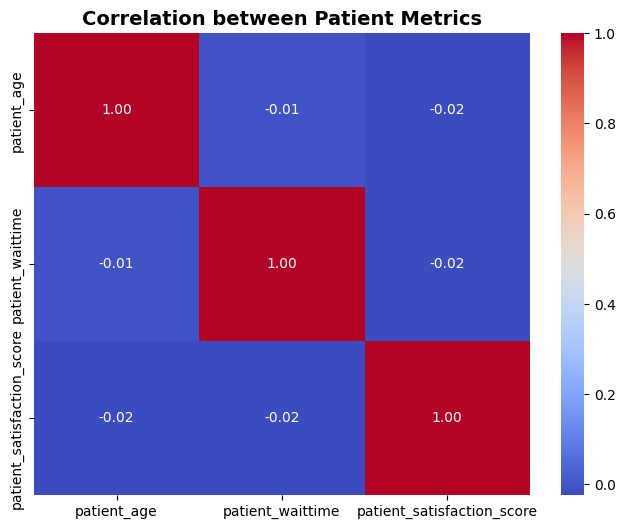

In [15]:
# 1. Select key numeric columns to analyze the linear relationships between patient variables
corr_columns = ['patient_age','patient_waittime','patient_satisfaction_score']
# 2. Calculate the Pearson Correlation Coefficient matrix to quantify the strength of relationships
correlation_matrix = df[corr_columns].corr()
# 3. Plot a heatmap with numerical annotations (annot=True) and a 'coolwarm' color scale
plt.figure(figsize=(8,6))
sns.heatmap(correlation_matrix,annot=True,cmap='coolwarm',fmt=".2f")
plt.title("Correlation between Patient Metrics", fontsize=14, fontweight='bold')
plt.show()

- **Zero Correlation:** There is effectively no relationship between patient age, wait time, and satisfaction scores, as all correlation coefficients are nearly zero (-0.01 to -0.02).
- **Independent Variables:** Changes in wait time do not appear to influence satisfaction scores in this dataset, suggesting other factors are driving patient sentiment.
- **Statistical Uniformity:** The data is highly uncorrelated, indicating that these specific metrics act independently of one another across the entire patient population.

- Advanced Distribution

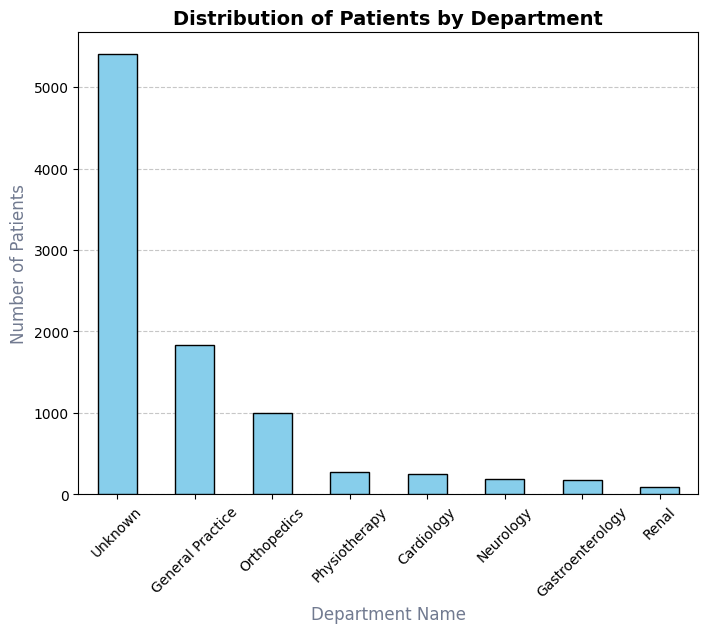

In [16]:
# 1. Initialize a professional 8x6 figure for high-impact visualization
plt.figure(figsize=(8,6))
# 2. Count patient records per department and plot as a bar chart with skyblue theme
# zorder=3 ensures the bars stay in front of the grid lines
df['department_referral'].value_counts().plot(kind='bar',color='skyblue',edgecolor='black',zorder=3)
# 3. Apply bold, standardized titles and labels for clear communication
plt.title('Distribution of Patients by Department', fontsize=14, fontweight='bold')
plt.xlabel("Department Name",fontsize=12, color='#717A90')
plt.ylabel("Number of Patients",fontsize=12, color='#717A90')
# 4. Rotate X-axis labels for readability and add a subtle background grid (zorder=0)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7, zorder=0)
plt.show()

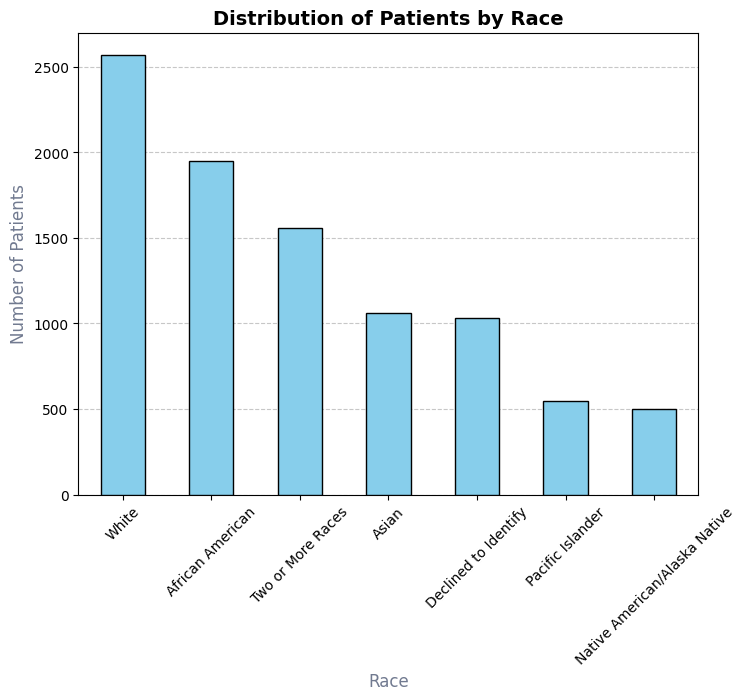

In [17]:
# 1. Initialize a professional 8x6 figure for high-impact visualization
plt.figure(figsize=(8,6))
# 2. Count patient records per race and plot as a bar chart with skyblue theme
# zorder=3 ensures the bars stay in front of the grid lines
df['patient_race'].value_counts().plot(kind='bar',color='skyblue',edgecolor='black',zorder=3)
# 3. Apply bold, standardized titles and labels for clear communication
plt.title('Distribution of Patients by Race', fontsize=14, fontweight='bold')
plt.xlabel("Race",fontsize=12, color='#717A90')
plt.ylabel("Number of Patients",fontsize=12, color='#717A90')
# 4. Rotate X-axis labels for readability and add a subtle background grid (zorder=0)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7, zorder=0)
plt.show()

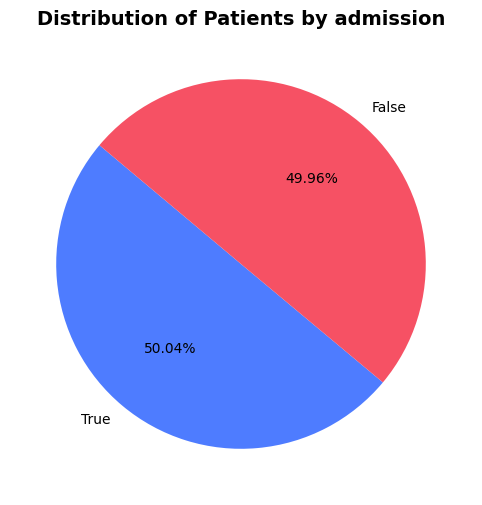

In [18]:
# 1. Initialize an 8x6 figure for a high-impact circular visualization
plt.figure(figsize=(8,6))
# 2. Count 'admission_flag' values and plot as a pie chart with percentage labels (autopct)
# startangle=140 is used to balance the visual weight of the categories
df['patient_admission_flag'].value_counts().plot(kind='pie',autopct='%1.2f%%',startangle=140,colors=['#4E7CFF', '#F65164'],ylabel='')
# 3. Apply bold, standardized titles for professional reporting
plt.title('Distribution of Patients by admission', fontsize=14, fontweight='bold')
plt.show()

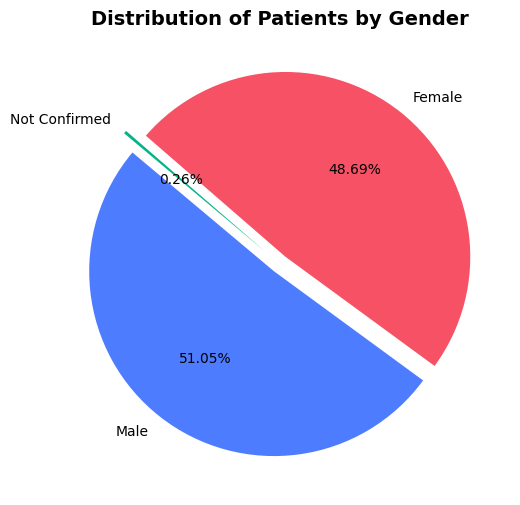

In [19]:
# 1. Initialize an 8x6 figure for a high-impact circular visualization
plt.figure(figsize=(8,6))
# 2. Count 'gender' values and plot as a pie chart with percentage labels (autopct)
# startangle=140 is used to balance the visual weight of the categories
df['patient_gender'].value_counts().plot(kind='pie',autopct='%1.2f%%',startangle=140,colors=['#4E7CFF', '#F65164', '#02B488'],explode=(0.05, 0.05, 0.1),ylabel='')
# 3. Apply bold, standardized titles for professional reporting
plt.title('Distribution of Patients by Gender', fontsize=14, fontweight='bold')
plt.show()

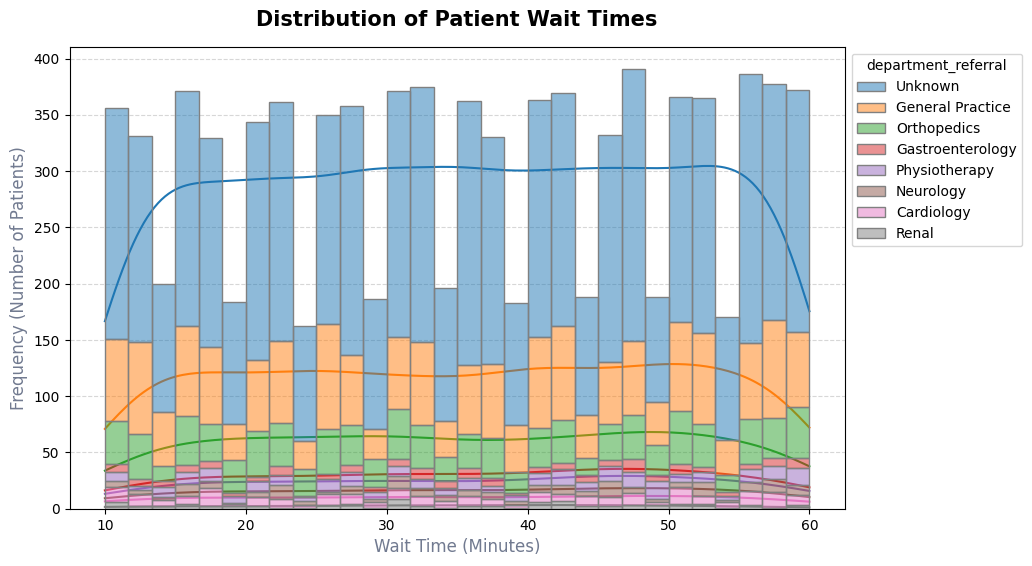

In [20]:
# 1. Initialize a large 10x6 figure to accommodate a complex multi-category visual
plt.figure(figsize=(10, 6))
# 2. Plot a stacked histogram with a Kernel Density Estimate (KDE) line
# multiple="stack" shows the total volume while revealing each department's contribution
ax = sns.histplot(data=df, x='patient_waittime',hue='department_referral',
                  bins=30,kde=True,color='#4E7CFF',edgecolor='gray',zorder=3,multiple="stack")
# 3. Position the legend outside the chart to maintain visibility of the 9,216 records
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
# 4. Apply bold titles and standardized axes for professional medical reporting
plt.title('Distribution of Patient Wait Times', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Wait Time (Minutes)', fontsize=12, color='#717A90')
plt.ylabel('Frequency (Number of Patients)', fontsize=12, color='#717A90')
# 5. Add a background grid with zorder=0 to keep the data bars in front
plt.grid(axis='y', linestyle='--', alpha=0.5, zorder=0)
plt.show()

-  Trend Analysis

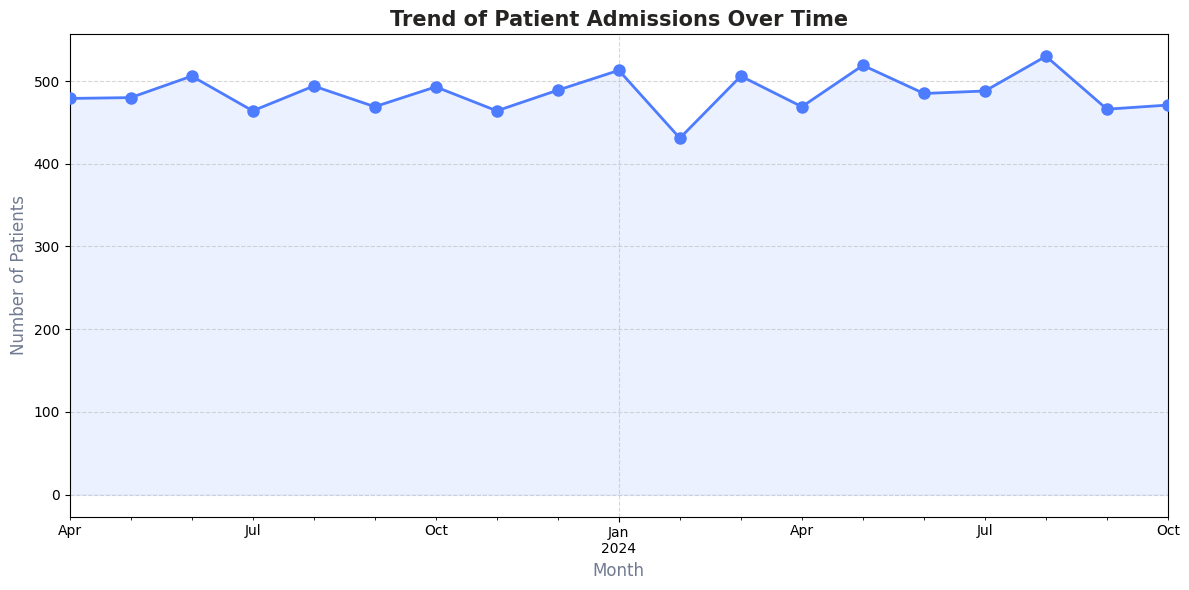

In [21]:
# Resample the dataset by month-end based on admission date
# and count the number of patients per month
monthly_data = df.resample('ME', on='patient_admission_date').size()

# Create a new figure with a specified size for better readability
plt.figure(figsize=(12, 6))

# Plot the monthly trend as a line chart with markers and styling
monthly_data.plot(
    kind='line',
    marker='o',
    color='#4E7CFF',
    linewidth=2,
    markersize=8,
    zorder=3
)

# Add a descriptive title to the chart
plt.title(
    'Trend of Patient Admissions Over Time',
    fontsize=15,
    fontweight='bold',
    color='#252423'
)

# Label the x-axis (time)
plt.xlabel('Month', fontsize=12, color='#717A90')

# Label the y-axis (patient count)
plt.ylabel('Number of Patients', fontsize=12, color='#717A90')

# Add a dashed grid in the background for easier value reading
plt.grid(True, linestyle='--', alpha=0.5, zorder=0)

# Fill the area under the line to enhance visual appeal
plt.fill_between(monthly_data.index, monthly_data, color='#4E7CFF', alpha=0.1)

# Adjust layout to prevent label/title cutoff
plt.tight_layout()

# Display the final plot
plt.show()

## 4. Database Integration

Automated Customer Data Ingestion Pipeline into SQL Server.

In [22]:
pip install sqlalchemy pyodbc

Note: you may need to restart the kernel to use updated packages.


In [23]:
import sqlalchemy as sa
import urllib
import warnings
from sqlalchemy import text

# Suppress technical version warnings
warnings.filterwarnings('ignore', category=sa.exc.SAWarning)

# Server connection settings (connect to 'master' first to ensure access)
connection_string = (
    'DRIVER={ODBC Driver 17 for SQL Server};'
    'SERVER=DESKTOP-V52VMJL;'
    'DATABASE=master;'
    'Trusted_Connection=yes;'
    'TrustServerCertificate=yes;'
)

params = urllib.parse.quote_plus(connection_string)
engine_master = sa.create_engine(f"mssql+pyodbc:///?odbc_connect={params}", isolation_level="AUTOCOMMIT")

try:
    # 1. Check and create the 'df' database automatically if it doesn't exist
    with engine_master.connect() as conn:
        exists = conn.execute(text("SELECT name FROM sys.databases WHERE name = 'df'")).fetchone()
        if not exists:
            conn.execute(text("CREATE DATABASE df"))
            print("--- Database 'df' created successfully ---")
        else:
            print("--- Database 'df' already exists ---")

    # 2. Switch the connection to the 'df' database
    params_df = urllib.parse.quote_plus(connection_string.replace('DATABASE=master;', 'DATABASE=df;'))
    engine_df = sa.create_engine(f"mssql+pyodbc:///?odbc_connect={params_df}", fast_executemany=True)

    # 3. Upload the data
    df.to_sql('patient', engine_df, if_exists='replace', index=False)
    print("✅ Success! Data uploaded to SQL Server.")

except Exception as e:
    print(f"❌ Failed: {e}")
    print("\n💡 Troubleshooting: Open SSMS, right-click your Server -> Properties -> Security -> ensure 'Windows Authentication' is enabled.")

--- Database 'df' already exists ---
✅ Success! Data uploaded to SQL Server.
